Importation des librairies

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from scipy.stats import linregress
from scipy.optimize import curve_fit

--- Démarrage de l'analyse ---
Traitement de : 0.8% Strain (LCF)...


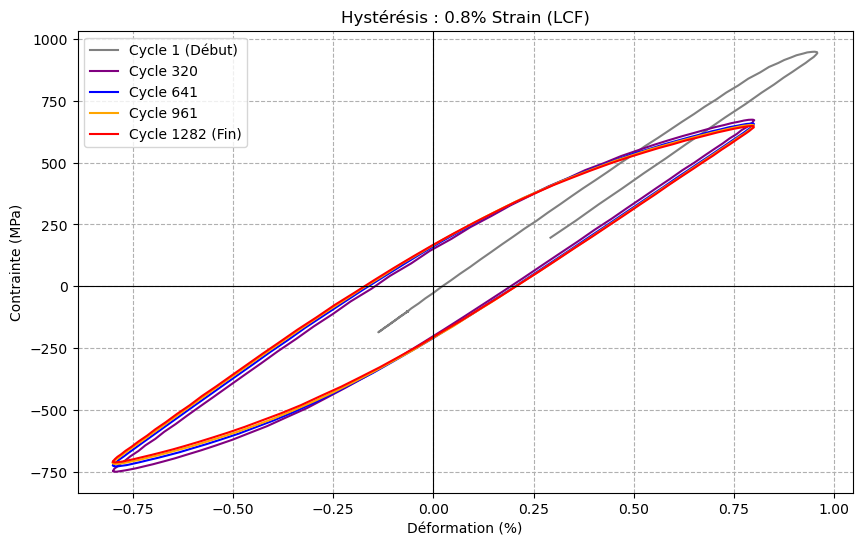

Traitement de : 1% Strain (LCF)...


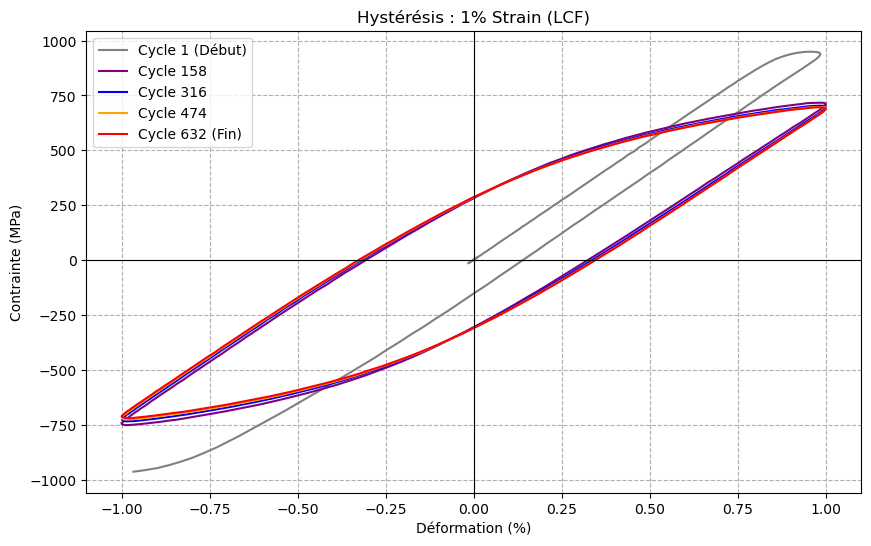

Traitement de : 1.2% Strain (LCF)...


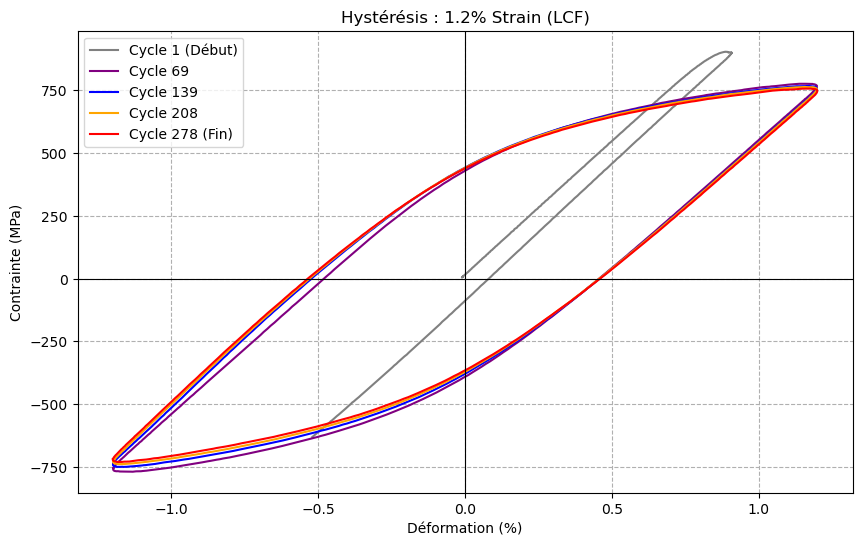

Traitement de : 800 MPa Stress (HCF)...


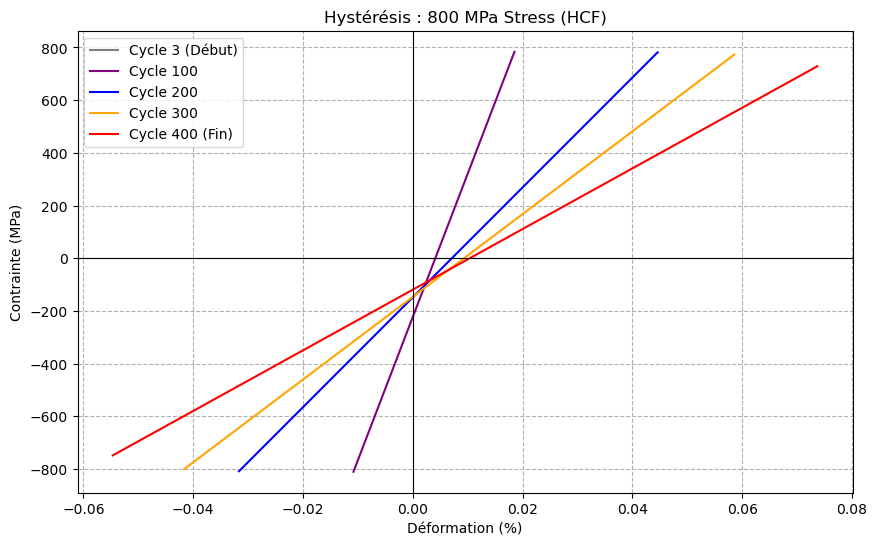

In [13]:


# --- 1. CONFIGURATION ---
# Liste des fichiers à analyser (Question I.5)
# On suppose que les fichiers sont dans le même dossier que ce Notebook
FILES_TO_PROCESS = [
    # LCF (Déformation imposée)
    {'filename': '0.8%.xlsx', 'label': '0.8% Strain (LCF)'},
    {'filename': '1%.xlsx',   'label': '1% Strain (LCF)'},
    {'filename': '1.2%.xlsx', 'label': '1.2% Strain (LCF)'},
    
    # HCF (Contrainte imposée) - Le sujet demande 800 MPa
    {'filename': '800 MPA.xlsx', 'label': '800 MPa Stress (HCF)'}
]

# Géométrie de l'éprouvette
AREA = 50.0  # mm^2
L0 = 10.0    # mm

def tracer_hysteresis(info):
    filename = info['filename']
    label = info['label']
    
    # On cherche le fichier dans le dossier courant ('.')
    if not os.path.exists(filename):
        print(f"⚠️  FICHIER INTROUVABLE : {filename}")
        print(f"    -> Assure-toi d'avoir uploadé '{filename}' dans Jupyter.")
        return

    print(f"Traitement de : {label}...")

    try:
        # Lecture du fichier Excel
        # skiprows=8 car les données commencent ligne 9
        df = pd.read_excel(filename, skiprows=8, engine='openpyxl')
        df = df.drop(0) # On enlève la ligne des unités

        # Nettoyage des colonnes (enlève les espaces)
        df.columns = df.columns.str.strip()

        # Identification intelligente des colonnes
        col_cycle = next((c for c in df.columns if 'Cycle' in c), None)
        col_force = next((c for c in df.columns if 'Force' in c), None)
        col_disp  = next((c for c in df.columns if 'Extenso' in c), None)

        if not (col_cycle and col_force and col_disp):
            print(f"  ❌ Colonnes manquantes dans {filename}")
            return

        # Conversion en nombres
        for col in [col_cycle, col_force, col_disp]:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        
        df = df.dropna(subset=[col_cycle, col_force, col_disp])

        # Calculs Contrainte / Déformation
        df['Stress_MPa'] = (df[col_force] * 1000) / AREA
        df['Strain_Pct'] = (df[col_disp] / L0) * 100

        # Sélection des cycles (1er, 20%, 40%, 60%, 80%)
        max_cycle = df[col_cycle].max()
        cycles_cibles = [1, max_cycle*0.2, max_cycle*0.4, max_cycle*0.6, max_cycle*0.8]
        cycles_a_tracer = sorted(list(set([int(c) for c in cycles_cibles if c >= 1])))

        # --- TRACÉ ---
        plt.figure(figsize=(10, 6))
        couleurs = ['grey', 'purple', 'blue', 'orange', 'red']

        for i, cyc in enumerate(cycles_a_tracer):
            # Trouver le cycle réel le plus proche
            cycle_reel = df.iloc[(df[col_cycle] - cyc).abs().argsort()[:1]][col_cycle].values[0]
            subset = df[df[col_cycle] == cycle_reel]
            
            # Légende
            txt = f"Cycle {cycle_reel}"
            if i == 0: txt += " (Début)"
            elif i == len(cycles_a_tracer)-1: txt += " (Fin)"

            plt.plot(subset['Strain_Pct'], subset['Stress_MPa'], 
                     label=txt, 
                     color=couleurs[i % len(couleurs)], 
                     linewidth=1.5)

        plt.title(f"Hystérésis : {label}")
        plt.xlabel("Déformation (%)")
        plt.ylabel("Contrainte (MPa)")
        plt.axhline(0, color='black', linewidth=0.8)
        plt.axvline(0, color='black', linewidth=0.8)
        plt.grid(True, linestyle='--')
        plt.legend()
        
        # Affichage direct dans le Notebook
        plt.show()

    except Exception as e:
        print(f"  ❌ Erreur technique sur {filename} : {e}")

# --- EXÉCUTION ---
# Installation silencieuse de openpyxl si nécessaire (pour lire les xlsx)
try:
    import openpyxl
except ImportError:
    print("Installation de openpyxl en cours...")
    !pip install openpyxl
    print("Installation terminée.")

print("--- Démarrage de l'analyse ---")
for f in FILES_TO_PROCESS:
    tracer_hysteresis(f)

--- Génération de la Courbe de Wöhler ---


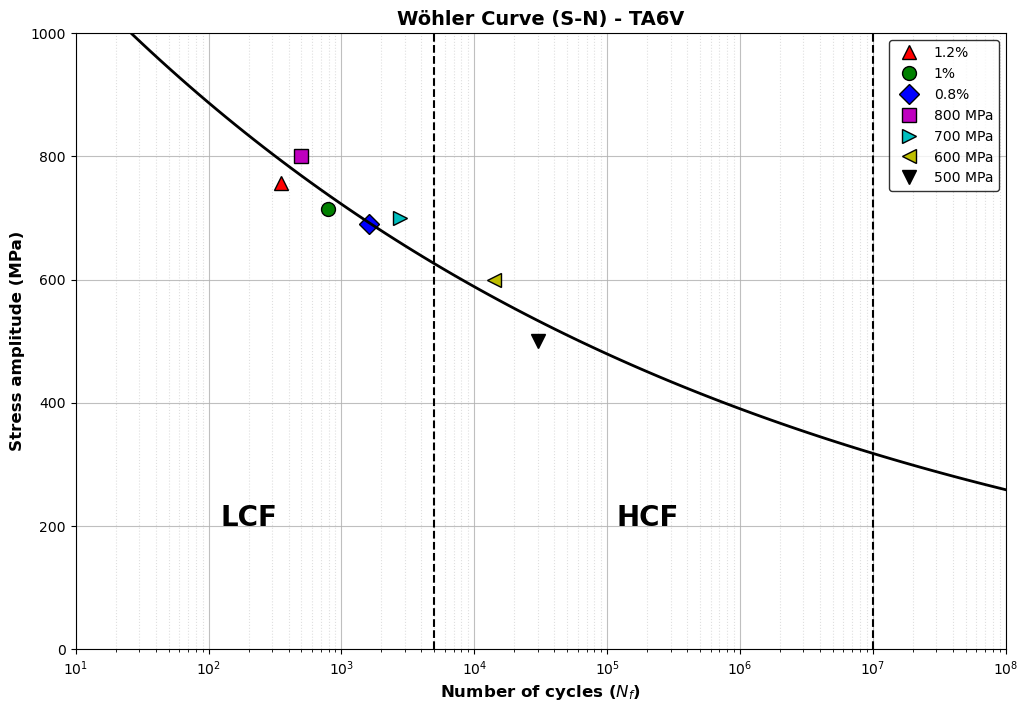

In [25]:
from scipy.stats import linregress

# --- 1. CONFIGURATION DU STYLE ---
# Chaque fichier a son propre marqueur (marker) et couleur
FILES_STYLE = [
    # LCF (Déformation)
    {'file': '1.2%.xlsx', 'label': '1.2%', 'type': 'strain', 'val': 1.2, 'fmt': '^r'}, # Triangle Rouge
    {'file': '1%.xlsx',   'label': '1%',   'type': 'strain', 'val': 1.0, 'fmt': 'og'}, # Rond Vert
    {'file': '0.8%.xlsx', 'label': '0.8%', 'type': 'strain', 'val': 0.8, 'fmt': 'Db'}, # Losange Bleu
    
    # HCF (Contrainte)
    {'file': '800 MPA.xlsx', 'label': '800 MPa', 'type': 'stress', 'val': 800, 'fmt': 'sm'}, # Carré Magenta
    {'file': '700 MPA.xlsx', 'label': '700 MPa', 'type': 'stress', 'val': 700, 'fmt': '>c'}, # Triangle Cyan
    {'file': '600 MPA.xlsx', 'label': '600 MPa', 'type': 'stress', 'val': 600, 'fmt': '<y'}, # Triangle Jaune
    {'file': '500 MPA.xlsx', 'label': '500 MPa', 'type': 'stress', 'val': 500, 'fmt': 'vk'}, # Triangle Bas Noir
    {'file': '400 MPA.xlsx', 'label': '400 MPa', 'type': 'stress', 'val': 400, 'fmt': 'pm'}, # Pentagone Violet
]

AREA = 50.0  # mm^2

all_nf = []
all_stress = []

plt.figure(figsize=(12, 8))

print("--- Génération de la Courbe de Wöhler ---")

# --- 2. TRAITEMENT DES FICHIERS ---
for item in FILES_STYLE:
    if not os.path.exists(item['file']):
        continue

    try:
        # Lecture Excel
        df = pd.read_excel(item['file'], skiprows=8, engine='openpyxl').drop(0)
        
        # Nettoyage
        df.columns = df.columns.str.strip()
        col_cycle = next((c for c in df.columns if 'Cycle' in c), None)
        col_force = next((c for c in df.columns if 'Force' in c), None)
        
        df[col_cycle] = pd.to_numeric(df[col_cycle], errors='coerce')
        df[col_force] = pd.to_numeric(df[col_force], errors='coerce')
        df = df.dropna(subset=[col_cycle, col_force])
        
        # Récupération Nf
        nf = df[col_cycle].max()
        
        # Récupération Contrainte
        if item['type'] == 'stress':
            stress = item['val']
        else:
            # LCF : Contrainte stabilisée à mi-vie
            mi_vie = int(nf / 2)
            cycle_reel = df.iloc[(df[col_cycle] - mi_vie).abs().argsort()[:1]][col_cycle].values[0]
            subset = df[df[col_cycle] == cycle_reel]
            stress = ((subset[col_force].max() - subset[col_force].min()) / 2 * 1000) / AREA

        # On garde les valeurs pour tracer la ligne de tendance
        all_nf.append(nf)
        all_stress.append(stress)

        # TRACÉ DU POINT
        marker = item['fmt'][0]
        color = item['fmt'][1]
        plt.plot(nf, stress, marker=marker, color=color, linestyle='None', 
                 markersize=10, markeredgecolor='black', label=item['label'])

    except Exception as e:
        print(f"  Erreur {item['file']}: {e}")

# --- 3. AJOUT DE LA LIGNE DE TENDANCE (La courbe S-N) ---
# On trace juste la ligne visuelle sans afficher l'équation
if all_nf:
    log_nf = np.log10(all_nf)
    log_s = np.log10(all_stress)
    slope, intercept, r, p, err = linregress(log_nf, log_s)
    
    # Ligne qui traverse tout le graphe
    x_line = np.logspace(1, 8, 100)
    y_line = (10**intercept) * (x_line ** slope)
    plt.plot(x_line, y_line, 'k-', linewidth=2)

# --- 4. MISE EN FORME (Style PDF) ---
plt.xscale('log')
plt.xlim(10, 10**8)   # De 10^1 à 10^8
plt.ylim(0, 1000)      # De 0 à 1000 MPa

plt.xlabel('Number of cycles ($N_f$)', fontsize=12, fontweight='bold')
plt.ylabel('Stress amplitude (MPa)', fontsize=12, fontweight='bold')
plt.title('Wöhler Curve (S-N) - TA6V', fontsize=14, fontweight='bold')

plt.grid(True, which="major", linestyle='-', alpha=0.8)
plt.grid(True, which="minor", linestyle=':', alpha=0.4)

# Délimitation visuelle LCF / HCF
plt.axvline(x=5000, color='black', linestyle='--', linewidth=1.5) 
plt.axvline(x=10**7, color='black', linestyle='--', linewidth=1.5)

# Textes sur le graphe
plt.text(200, 200, 'LCF', fontsize=20, fontweight='bold', ha='center', color='black')
plt.text(2*10**5, 200, 'HCF', fontsize=20, fontweight='bold', ha='center', color='black')

plt.legend(loc='upper right', frameon=True, edgecolor='black')
plt.show()

--- Génération de la Courbe Strain-Life (Manson-Coffin) ---


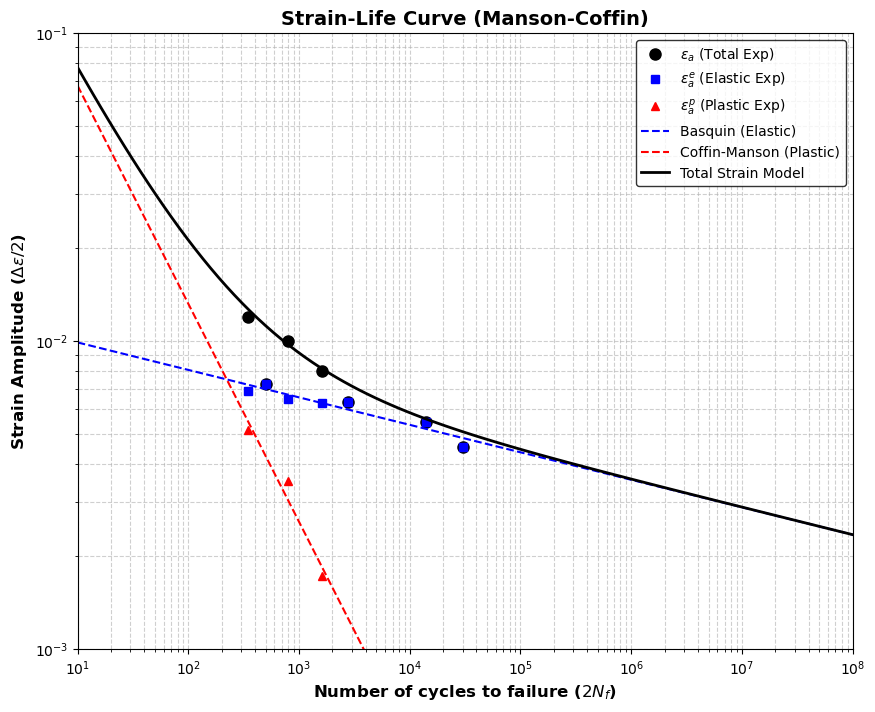


1. LOI DE RAMBERG-OSGOOD
   Sigma_a = K' * (Ep)^n'
   -> n' (Exposant d'écrouissage cyclique) : 0.0785
   -> K' (Coefficient de résistance cyclique) : 1131.62 MPa

2. LOI DE BASQUIN (Partie Élastique)
   E_el = (Sigma_f' / E) * (Nf)^b
   -> b (Exposant de résistance à la fatigue)  : -0.0892
   -> Sigma_f' (Coeff. de résistance à la fatigue): 1337.42 MPa

3. LOI DE COFFIN-MANSON (Partie Plastique)
   E_pl = Epsilon_f' * (Nf)^c
   -> c (Exposant de ductilité à la fatigue)   : -0.7079
   -> Epsilon_f' (Coeff. de ductilité à la fatigue): 0.3445


In [23]:
# --- 1. CONFIGURATION ---
# On sépare LCF (pour la plasticité) et HCF (pour l'élasticité)
FILES_LCF = [
    {'file': '1.2%.xlsx', 'val': 1.2, 'label': '1.2%'},
    {'file': '1%.xlsx',   'val': 1.0, 'label': '1%'},
    {'file': '0.8%.xlsx', 'val': 0.8, 'label': '0.8%'}
]

FILES_HCF = [
    {'file': '800 MPA.xlsx', 'val': 800},
    {'file': '700 MPA.xlsx', 'val': 700},
    {'file': '600 MPA.xlsx', 'val': 600},
    {'file': '500 MPA.xlsx', 'val': 500},
    {'file': '400 MPA.xlsx', 'val': 400}
]

AREA = 50.0       # mm^2
L0 = 10.0         # mm
E_YOUNG = 110000  # MPa (Module de Young)

# Listes pour stocker les points
nf_list = []
eps_total_list = []
eps_elastic_list = []
eps_plastic_list = []

# Listes spécifiques pour les régressions
reg_elastic_nf = []
reg_elastic_val = []
reg_plastic_nf = []
reg_plastic_val = []

print("--- Génération de la Courbe Strain-Life (Manson-Coffin) ---")

# --- 2. EXTRACTION DES DONNÉES ---

# A. Traitement des fichiers LCF (Déformation imposée)
for item in FILES_LCF:
    if not os.path.exists(item['file']): continue
    try:
        df = pd.read_excel(item['file'], skiprows=8, engine='openpyxl').drop(0)
        df.columns = df.columns.str.strip()
        col_cyc = next(c for c in df.columns if 'Cycle' in c)
        col_for = next(c for c in df.columns if 'Force' in c)
        col_ext = next(c for c in df.columns if 'Extenso' in c)
        
        for c in [col_cyc, col_for, col_ext]: df[c] = pd.to_numeric(df[c], errors='coerce')
        df = df.dropna(subset=[col_cyc, col_for, col_ext])

        # Cycle stabilisé (Mi-vie)
        nf = df[col_cyc].max()
        mid_life = int(nf/2)
        row = df.iloc[(df[col_cyc]-mid_life).abs().argsort()[:1]]
        cycle_reel = row[col_cyc].values[0]
        subset = df[df[col_cyc] == cycle_reel]

        # Calcul des amplitudes
        force_amp = (subset[col_for].max() - subset[col_for].min()) / 2
        sigma_a = (force_amp * 1000) / AREA  # Contrainte (MPa)
        
        disp_amp = (subset[col_ext].max() - subset[col_ext].min()) / 2
        epsilon_total = disp_amp / L0        # Déformation Totale (mm/mm)

        # Décomposition : Totale = Elastique + Plastique
        epsilon_elastic = sigma_a / E_YOUNG
        epsilon_plastic = epsilon_total - epsilon_elastic

        # Stockage
        nf_list.append(nf)
        eps_total_list.append(epsilon_total)
        eps_elastic_list.append(epsilon_elastic)
        eps_plastic_list.append(epsilon_plastic)

        # Ajout aux listes de régression
        reg_elastic_nf.append(nf)
        reg_elastic_val.append(epsilon_elastic)
        if epsilon_plastic > 0.0001: # On ne garde que si plastique significatif
            reg_plastic_nf.append(nf)
            reg_plastic_val.append(epsilon_plastic)

    except: pass

# B. Traitement des fichiers HCF (Contrainte imposée)
for item in FILES_HCF:
    if not os.path.exists(item['file']): continue
    try:
        df = pd.read_excel(item['file'], skiprows=8, engine='openpyxl').drop(0)
        col_cyc = next(c for c in df.columns if 'Cycle' in c)
        df[col_cyc] = pd.to_numeric(df[col_cyc], errors='coerce')
        nf = df[col_cyc].max()
        
        # En HCF, on impose la contrainte
        sigma_a = item['val']
        epsilon_elastic = sigma_a / E_YOUNG
        
        # En HCF, plastique est négligeable (~0)
        # On ajoute donc uniquement à la composante élastique
        nf_list.append(nf)
        eps_elastic_list.append(epsilon_elastic)
        eps_total_list.append(epsilon_elastic) # Totale approx Elastique
        
        reg_elastic_nf.append(nf)
        reg_elastic_val.append(epsilon_elastic)
    except: pass

# --- 3. CALCUL DES LOIS (RÉGRESSIONS) ---

# Loi Élastique (Basquin ramené en déformation) : E_el = (Sf'/E) * Nf^b
slope_e, intercept_e, _, _, _ = linregress(np.log10(reg_elastic_nf), np.log10(reg_elastic_val))
b = slope_e
coeff_elastic = 10**intercept_e # Ceci est égal à Sf'/E

# Loi Plastique (Coffin-Manson) : E_pl = Ef' * Nf^c
slope_p, intercept_p, _, _, _ = linregress(np.log10(reg_plastic_nf), np.log10(reg_plastic_val))
c = slope_p
coeff_plastic = 10**intercept_p # Ceci est Ef'

# --- 4. TRACÉ DU GRAPHIQUE ---
plt.figure(figsize=(10, 8))

# A. Points Expérimentaux
plt.loglog(nf_list, eps_total_list, 'ko', markersize=8, label='$\epsilon_{a}$ (Total Exp)')
plt.loglog(nf_list, eps_elastic_list, 'bs', markersize=6, label='$\epsilon_{a}^{e}$ (Elastic Exp)')
plt.loglog(reg_plastic_nf, reg_plastic_val, 'r^', markersize=6, label='$\epsilon_{a}^{p}$ (Plastic Exp)')

# B. Courbes Modèles
x_model = np.logspace(1, 8, 100) # De 10 à 10^8 cycles

# Ligne Élastique (Basquin)
y_elastic = coeff_elastic * (x_model ** b)
plt.loglog(x_model, y_elastic, 'b--', linewidth=1.5, label='Basquin (Elastic)')

# Ligne Plastique (Coffin-Manson)
y_plastic = coeff_plastic * (x_model ** c)
plt.loglog(x_model, y_plastic, 'r--', linewidth=1.5, label='Coffin-Manson (Plastic)')

# Courbe Totale (Somme)
y_total = y_elastic + y_plastic
plt.loglog(x_model, y_total, 'k-', linewidth=2, label='Total Strain Model')

# --- 5. MISE EN FORME ---
plt.xlabel('Number of cycles to failure ($2N_f$)', fontsize=12, fontweight='bold')
plt.ylabel('Strain Amplitude ($\Delta \\varepsilon / 2$)', fontsize=12, fontweight='bold')
plt.title('Strain-Life Curve (Manson-Coffin)', fontsize=14, fontweight='bold')

plt.grid(True, which="both", linestyle='--', alpha=0.6)
plt.legend(loc='best', frameon=True, edgecolor='black')

plt.xlim(10, 10**8)
# Limite Y ajustée pour bien voir les données (ex: 0.001 à 0.1, soit 0.1% à 10%)
plt.ylim(0.001, 0.1) 

plt.show()

# --- ÉTAPE 2 : CALCULS NUMÉRIQUES (RÉGRESSIONS) ---

print("\n" + "="*60)
print("="*60)

# 1. PARAMÈTRES RAMBERG-OSGOOD (Eq. 1)
# Relation: log(Sigma_a) = n' * log(Ep) + log(K')
if len(ro_ep) > 1:
    slope, intercept, r, _, _ = linregress(np.log10(ro_ep), np.log10(ro_sigma))
    n_prime = slope
    K_prime = 10**intercept
    print(f"1. LOI DE RAMBERG-OSGOOD")
    print(f"   Sigma_a = K' * (Ep)^n'")
    print(f"   -> n' (Exposant d'écrouissage cyclique) : {n_prime:.4f}")
    print(f"   -> K' (Coefficient de résistance cyclique) : {K_prime:.2f} MPa")
else:
    print("1. RAMBERG-OSGOOD : Pas assez de données plastiques.")

# 2. PARAMÈTRES BASQUIN (Partie Élastique de Eq. 2)
# Relation: log(E_el) = b * log(Nf) + log(Sf'/E)
slope, intercept, r, _, _ = linregress(np.log10(cmb_nf), np.log10(cmb_e_elast))
b = slope
Sf_prime = (10**intercept) * E_YOUNG
print(f"\n2. LOI DE BASQUIN (Partie Élastique)")
print(f"   E_el = (Sigma_f' / E) * (Nf)^b")
print(f"   -> b (Exposant de résistance à la fatigue)  : {b:.4f}")
print(f"   -> Sigma_f' (Coeff. de résistance à la fatigue): {Sf_prime:.2f} MPa")

# 3. PARAMÈTRES COFFIN-MANSON (Partie Plastique de Eq. 2)
# Relation: log(E_pl) = c * log(Nf) + log(Ef')
if len(cmb_e_plast) > 1:
    # On filtre pour ne prendre que les Nf correspondants aux points plastiques (LCF)
    # Les listes cmb_e_plast et les Nf correspondants sont synchronisés au début de la liste
    nf_lcf = cmb_nf[:len(cmb_e_plast)] 
    slope, intercept, r, _, _ = linregress(np.log10(nf_lcf), np.log10(cmb_e_plast))
    c = slope
    Ef_prime = 10**intercept
    print(f"\n3. LOI DE COFFIN-MANSON (Partie Plastique)")
    print(f"   E_pl = Epsilon_f' * (Nf)^c")
    print(f"   -> c (Exposant de ductilité à la fatigue)   : {c:.4f}")
    print(f"   -> Epsilon_f' (Coeff. de ductilité à la fatigue): {Ef_prime:.4f}")
else:
    print("3. COFFIN-MANSON : Pas assez de données plastiques.")
print("="*60)

--- PARTIE IV : PARAMÈTRES DU MODÈLE DE COMPORTEMENT (1.2%.xlsx) ---

>>> 1. Analyse Écrouissage Isotrope (Isotropic Hardening)
   Sigma_Y0 (Yield initial): 926.5 MPa
   Q (Isotropic Limit)     : -5892059.9 MPa
   b (Isotropic Speed)     : 0.0000


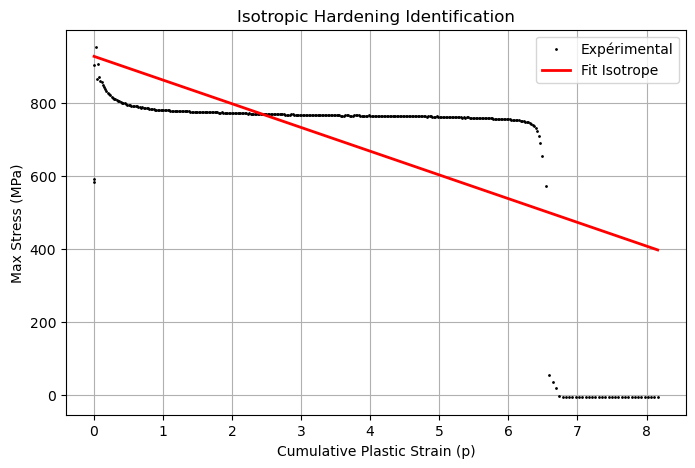


>>> 2. Analyse Écrouissage Cinématique (Kinematic Hardening)
   Sigma_Y (Cyclic Yield)  : 333.3 MPa
   C (Kinematic Modulus)   : 664899.4 MPa
   Gamma (Recall param)    : 1685.0


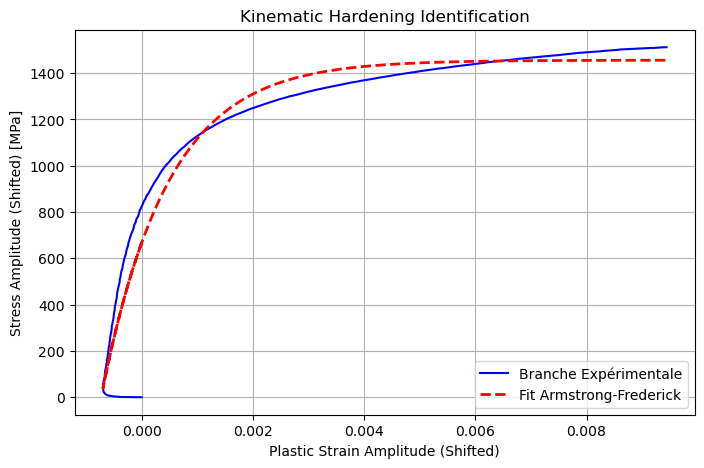

In [22]:
# --- CONFIGURATION ---
FILE_TARGET = '1.2%.xlsx'  # Essai avec le plus de plasticité
AREA = 50.0        # mm^2
L0 = 10.0          # mm
E_YOUNG = 110000.0 # MPa

print(f"--- PARTIE IV : PARAMÈTRES DU MODÈLE DE COMPORTEMENT ({FILE_TARGET}) ---")

if not os.path.exists(FILE_TARGET):
    print(f"ERREUR : Le fichier {FILE_TARGET} est introuvable.")
else:
    # 1. Chargement et Nettoyage
    df = pd.read_excel(FILE_TARGET, skiprows=8, engine='openpyxl').drop(0)
    col_cyc = next(c for c in df.columns if 'Cycle' in c)
    col_for = next(c for c in df.columns if 'Force' in c)
    col_ext = next(c for c in df.columns if 'Extenso' in c)
    
    for c in [col_cyc, col_for, col_ext]: df[c] = pd.to_numeric(df[c], errors='coerce')
    df = df.dropna(subset=[col_cyc, col_for, col_ext])

    # Calculs initiaux
    df['Stress'] = (df[col_for] * 1000) / AREA
    # Si l'extensomètre est en mm, diviser par L0 pour avoir la déformation sans unité
    df['Strain'] = df[col_ext] / L0 
    
    # ---------------------------------------------------------
    # A. ÉCROUISSAGE ISOTROPE (Q, b) - Adoucissement Cyclique
    # ---------------------------------------------------------
    print("\n>>> 1. Analyse Écrouissage Isotrope (Isotropic Hardening)")
    
    cycles = df[col_cyc].unique()
    iso_data = []

    # On parcourt les cycles (avec un pas pour accélérer si nécessaire)
    step = 1 if len(cycles) < 1000 else 10
    
    for cyc in cycles[::step]:
        # --- CORRECTION DU WARNING ICI : ajout de .copy() ---
        subset = df[df[col_cyc] == cyc].copy()
        
        if len(subset) < 5: continue
        
        sigma_max = subset['Stress'].max()
        
        # Calcul approximatif de la largeur plastique pour cumuler p
        subset['Ep_temp'] = subset['Strain'] - subset['Stress']/E_YOUNG
        delta_ep = subset['Ep_temp'].max() - subset['Ep_temp'].min()
        
        iso_data.append({
            'Cycle': cyc,
            'Sigma_Max': sigma_max,
            'Delta_Ep': delta_ep
        })
    
    df_iso = pd.DataFrame(iso_data)
    
    # Calcul de p (déformation plastique cumulée)
    # p = Somme(2 * Delta_Ep) à chaque cycle
    df_iso['p'] = (2 * df_iso['Delta_Ep']).cumsum()
    
    # Modèle : R = R0 + Q * (1 - exp(-b*p))
    def isotropic_law(p, R0, Q, b):
        return R0 + Q * (1 - np.exp(-b * p))
    
    # Fit
    try:
        p_vals = df_iso['p'].values
        s_vals = df_iso['Sigma_Max'].values
        # Initial guess : Q négatif pour l'adoucissement
        p0_iso = [s_vals[0], -100, 5] 
        popt_iso, _ = curve_fit(isotropic_law, p_vals, s_vals, p0=p0_iso, maxfev=5000)
        
        R0_fit, Q_fit, b_fit = popt_iso
        
        print(f"   Sigma_Y0 (Yield initial): {R0_fit:.1f} MPa")
        print(f"   Q (Isotropic Limit)     : {Q_fit:.1f} MPa")
        print(f"   b (Isotropic Speed)     : {b_fit:.4f}")

        # Graphique Isotrope
        plt.figure(figsize=(8, 5))
        plt.plot(p_vals, s_vals, 'k.', markersize=2, label='Expérimental')
        plt.plot(p_vals, isotropic_law(p_vals, *popt_iso), 'r-', linewidth=2, label='Fit Isotrope')
        plt.xlabel('Cumulative Plastic Strain (p)')
        plt.ylabel('Max Stress (MPa)')
        plt.title('Isotropic Hardening Identification')
        plt.legend()
        plt.grid(True)
        plt.show()
        
    except Exception as e:
        print(f"Erreur Fit Isotrope: {e}")

    # ---------------------------------------------------------
    # B. ÉCROUISSAGE CINÉMATIQUE (C, Gamma) - Boucle Stabilisée
    # ---------------------------------------------------------
    print("\n>>> 2. Analyse Écrouissage Cinématique (Kinematic Hardening)")
    
    # On prend le cycle stabilisé (mi-vie)
    mid_life = int(df[col_cyc].max() / 2)
    # --- CORRECTION DU WARNING ICI AUSSI ---
    df_stab = df[df[col_cyc] == mid_life].copy()
    
    # Calcul Ep précis
    df_stab['Ep'] = df_stab['Strain'] - df_stab['Stress'] / E_YOUNG
    
    # Extraction de la branche montante (Compression -> Traction)
    idx_min = df_stab['Stress'].idxmin()
    idx_max = df_stab['Stress'].idxmax()
    
    # Gestion de l'ordre des indices pour extraire la montée
    if idx_min < idx_max:
        branch = df_stab.loc[idx_min:idx_max].copy()
    else:
        # Si le cycle est coupé, on prend la descente et on inverse (symétrie)
        branch = df_stab.loc[idx_max:idx_min].copy()
        branch['Stress'] = -branch['Stress']
        branch['Ep'] = -branch['Ep']

    # Recalage à zéro (Translation)
    ep_data = branch['Ep'].values - branch['Ep'].values[0]
    stress_data = branch['Stress'].values - branch['Stress'].values[0]
    
    # Modèle Armstrong-Frederick (Branche) :
    # Delta_Sigma = 2*Sigma_Y + (2*C/Gamma) * (1 - exp(-Gamma * Delta_Ep/2))
    def kinematic_law(dep, sy, C, gamma):
        return 2*sy + (2*C/gamma) * (1 - np.exp(-gamma * (dep/2.0)))
    
    try:
        # Fit
        p0_kin = [R0_fit, 50000, 200] # On réutilise R0 trouvé précédemment comme estimation
        # Bornes pour éviter les valeurs aberrantes (Gamma doit être positif)
        bounds_kin = ([0, 0, 0], [2000, 1e6, 5000]) 
        
        popt_kin, _ = curve_fit(kinematic_law, ep_data, stress_data, p0=p0_kin, bounds=bounds_kin)
        sy_kin, C_fit, gamma_fit = popt_kin
        
        print(f"   Sigma_Y (Cyclic Yield)  : {sy_kin:.1f} MPa")
        print(f"   C (Kinematic Modulus)   : {C_fit:.1f} MPa")
        print(f"   Gamma (Recall param)    : {gamma_fit:.1f}")
        
        # Graphique Cinématique 
        plt.figure(figsize=(8, 5))
        plt.plot(ep_data, stress_data, 'b-', label='Branche Expérimentale')
        plt.plot(ep_data, kinematic_law(ep_data, *popt_kin), 'r--', linewidth=2, label='Fit Armstrong-Frederick')
        plt.xlabel('Plastic Strain Amplitude (Shifted)')
        plt.ylabel('Stress Amplitude (Shifted) [MPa]')
        plt.title('Kinematic Hardening Identification')
        plt.legend()
        plt.grid(True)
        plt.show()

    except Exception as e:
        print(f"Erreur Fit Cinématique: {e}")

print("="*50)